[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/RO/capitol8_notebook_seminar.ipynb)

# Modelarea piețelor financiare — Seminarul 8: Backtesting și evaluarea prognozelor de risc

*Notebook de seminar. Daniel Traian Pele, Antoaneta Amza — Academia de Studii Economice din București.*

- **Partea A**: verificarea numerică a celor nouă exerciții pe hârtie.
- **Partea B**: backtesting și inferență pe S&P 500, BET, Bitcoin și EUR/RON.
- **Partea C**: ce model de risc ați certifica pentru portofoliul de tranzacționare al unei bănci românești? O analiză de referință.
- Problemele **[Rezolvat]** sunt lucrate complet (cod și rezultat); problemele **[Propus]** au o celulă goală pentru voi: rezolvările se discută la seminar.
- Modele: A2 după A1; A4 după A3; A9 după A6; B2 după A5 și B1; B4 după B3; B6 după B5; B8 după B7.

> Rezolvările se discută la seminar.

In [ ]:
import os
import sys
import subprocess
try:
    import arch  # GARCH estimation
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'arch'], check=True)
import pickle
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats, optimize
from numpy.lib.stride_tricks import sliding_window_view
import warnings
warnings.filterwarnings('ignore')

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# copia locala a folderului data/market, daca notebook-ul ruleaza din repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

# nume -> (simbol, data de start); indici/cripto: pretul de inchidere
SOURCES = {
    'sp500':  ('GSPC.INDX', '1990-01-01'),
    'bet':    ('BET', '1997-09-19'),
    'btc':    ('BTC-USD.CC', '2014-09-17'),
    'eurron': ('REF:EUR', '2005-07-01'),        # cursul de referinta BNR, de la introducerea leului nou
}
LABELS = {'sp500': 'S&P 500', 'bet': 'BET', 'btc': 'Bitcoin', 'eurron': 'EUR/RON'}
ASSETS = list(SOURCES)

_CACHE = {}


def read_market(symbol):
    """Citeste data/market/<SIMBOL>.csv local sau din repo-ul GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Cursul oficial de referinta RON publicat de BNR (arhive XML anuale)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_price(name):
    """Seria de preturi (inchidere) a activului."""
    symbol, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    p = read_market(symbol)['close'].loc[start:]
    return p[p > 0].dropna()


def load_returns(name):
    """Randamente log zilnice pe calendarul propriu al seriei."""
    return np.log(load_price(name)).diff().dropna()


# =============================================================================
# PROGNOZE VaR / ES PE FEREASTRA MOBILA (o zi inainte)
# =============================================================================
W = 1000                       # fereastra de estimare (observatii)
REFIT = 20                     # parametrii GARCH / t / EVT se reestimeaza la fiecare 20 de zile
LEVELS = (0.01, 0.025, 0.05)   # probabilitati de coada: VaR 1%, VaR 2.5%, VaR 5%
A_ES = 0.025                   # ES 2.5% (FRTB)
K_TAIL = int(np.ceil(A_ES * W))   # numarul de statistici de ordine din coada (simularea Z2)
MODELS = ['HS', 'Normal', 'Student-t', 'GARCH-t', 'FHS', 'GARCH-EVT']
EVAL_FROM = '2007-01-01'       # prima zi posibila de evaluare
EVT_Q = 0.90                   # pragul POT: cuantila 90% a pierderilor standardizate


def t_std_q(nu, a):
    """Cuantila 1-a a distributiei Student-t standardizate (dispersie 1)."""
    return stats.t.ppf(1 - a, nu) * np.sqrt((nu - 2) / nu)


def t_std_es(nu, a):
    """ES la nivelul 1-a al distributiei Student-t standardizate (dispersie 1)."""
    q = stats.t.ppf(1 - a, nu)
    return stats.t.pdf(q, nu) / a * (nu + q ** 2) / (nu - 1) * np.sqrt((nu - 2) / nu)


def garch_fit(x, prev=None):
    """GARCH(1,1) cu inovatii Student-t, prin verosimilitate maxima; parametri in unitati zecimale.
    Seria este rescalata la dispersie unitara pentru stabilitate numerica; daca optimizarea esueaza,
    se pastreaza parametrii estimati anterior."""
    from arch import arch_model
    c = 1 / x.std()
    res = arch_model(c * x, mean='Constant', vol='GARCH', p=1, q=1, dist='t',
                     rescale=False).fit(disp='off', show_warning=False)
    mu, om, a, b, nu = res.params.values
    ok = res.convergence_flag == 0 and abs(mu) < 1 and a + b < 1 and om > 0
    if not ok and prev is not None:
        return prev
    return mu / c, om / c ** 2, a, b, nu


def garch_filter(x, mu, om, a, b, s2_0):
    """Dispersia conditionata: s2[t] foloseste doar x[:t]; ultimul element este prognoza."""
    e2 = (x - mu) ** 2
    s2 = np.empty(len(x) + 1)
    s2[0] = s2_0
    for t in range(len(x)):
        s2[t + 1] = om + a * e2[t] + b * s2[t]
    return s2


def gpd_tail(y, a_list, q=EVT_Q):
    """EVT (POT): GPD pe excedentele pierderilor standardizate peste cuantila q; VaR/ES la nivelurile 1-a."""
    u = np.quantile(y, q)
    exc = y[y > u] - u
    xi, _, beta = stats.genpareto.fit(exc, floc=0)
    pu = len(exc) / len(y)
    var = {a: u + beta / xi * ((a / pu) ** (-xi) - 1) for a in a_list}
    es = {a: (var[a] + beta - xi * u) / (1 - xi) for a in a_list}
    return dict(u=u, xi=xi, beta=beta, pu=pu, var=var, es=es)


def gpd_cdf(y, g, emp):
    """Functia de repartitie EVT: empirica sub prag, GPD deasupra pragului."""
    if y <= g['u']:
        return np.mean(emp <= y)
    base = 1 + g['xi'] * (y - g['u']) / g['beta']
    return 1.0 if base <= 0 else 1 - g['pu'] * base ** (-1 / g['xi'])


def rolling_forecasts(r, eval_from=EVAL_FROM, w=W, refit=REFIT):
    """Prognoze VaR (LEVELS) si ES (A_ES) la o zi pentru pierderea L = -r, cu toate modelele.

    Rezultat: dict model -> DataFrame (index = ziua prognozata) cu coloanele
    VaR1, VaR2.5, VaR5, ES2.5, ES1, pit (F(L_t)), scale, mu, plus informatii pentru simularea cozii."""
    r = r.dropna()
    L = -r.values
    idx = r.index
    start = max(w, int(np.searchsorted(idx, pd.Timestamp(eval_from))))
    T = len(r) - start
    days = idx[start:]
    out = {m: {k: np.full(T, np.nan) for k in ['VaR1', 'VaR2.5', 'VaR5', 'ES2.5', 'ES1', 'pit', 'scale', 'mu', 'nu',
                                               'u', 'xi', 'beta', 'pu']} for m in MODELS}
    tails = {m: np.full((T, K_TAIL), np.nan) for m in ('HS', 'FHS')}
    lev = {0.01: 'VaR1', 0.025: 'VaR2.5', 0.05: 'VaR5'}
    Lcur = L[start:]

    # --- HS si Normal: vectorizat pe ferestre
    win = sliding_window_view(L[:-1], w)[start - w:]          # fereastra pentru ziua t: L[t-w:t]
    srt = np.sort(win, axis=1)
    o = out['HS']
    for a, k in lev.items():
        o[k] = np.quantile(win, 1 - a, axis=1)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        v = np.quantile(win, 1 - a, axis=1)
        o[k] = np.nanmean(np.where(win >= v[:, None], win, np.nan), axis=1)
    o['pit'] = (np.sum(win < Lcur[:, None], axis=1) + 0.5 * np.sum(win == Lcur[:, None], axis=1)) / w
    o['scale'] = win.std(axis=1, ddof=1)
    o['mu'] = np.zeros(T)
    tails['HS'] = srt[:, -K_TAIL:]
    mu_w, sd_w = -win.mean(axis=1), win.std(axis=1, ddof=1)     # medie a randamentelor, abatere standard
    o = out['Normal']
    for a, k in lev.items():
        o[k] = -mu_w + sd_w * stats.norm.ppf(1 - a)
    for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
        o[k] = -mu_w + sd_w * stats.norm.pdf(stats.norm.ppf(1 - a)) / a
    o['pit'] = stats.norm.cdf((Lcur + mu_w) / sd_w)
    o['scale'], o['mu'] = sd_w, mu_w

    # --- modele reestimate la fiecare `refit` zile
    prev = None
    for b0 in range(0, T, refit):
        t0 = start + b0
        b1 = min(T, b0 + refit)
        x = r.values[t0 - w:t0]
        # Student-t neconditionat: grade de libertate, locatie si scala prin MLE
        nu_t, loc_t, sc_t = stats.t.fit(x)
        nu_t = max(nu_t, 2.2)
        sd_t = sc_t * np.sqrt(nu_t / (nu_t - 2))                # abaterea standard implicata
        # GARCH(1,1)-t
        prev = garch_fit(x, prev if b0 > 0 else None)
        mu, om, al, be, nu = prev
        nu = max(nu, 2.2)
        xx = r.values[t0 - w:t0 + (b1 - b0)]
        s2 = garch_filter(xx, mu, om, al, be, np.var(x[:50]))
        z = (x - mu) / np.sqrt(s2[:w])
        y = np.sort(-z)                                         # pierderi standardizate
        g = gpd_tail(y, (0.01, 0.025, 0.05))
        for t in range(b0, b1):
            j = w + (t - b0)
            sig = np.sqrt(s2[j])
            Lt = Lcur[t]
            # Student-t neconditionat
            o = out['Student-t']
            for a, k in lev.items():
                o[k][t] = -loc_t + sd_t * t_std_q(nu_t, a)
            o['ES2.5'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.025)
            o['ES1'][t] = -loc_t + sd_t * t_std_es(nu_t, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + loc_t) / sc_t, nu_t)
            o['scale'][t], o['mu'][t], o['nu'][t] = sd_t, loc_t, nu_t
            # GARCH-t
            o = out['GARCH-t']
            for a, k in lev.items():
                o[k][t] = -mu + sig * t_std_q(nu, a)
            o['ES2.5'][t] = -mu + sig * t_std_es(nu, 0.025)
            o['ES1'][t] = -mu + sig * t_std_es(nu, 0.01)
            o['pit'][t] = stats.t.cdf((Lt + mu) / sig / np.sqrt((nu - 2) / nu), nu)
            o['scale'][t], o['mu'][t], o['nu'][t] = sig, mu, nu
            # FHS: cuantilele empirice ale pierderilor standardizate
            o = out['FHS']
            for a, k in lev.items():
                o[k][t] = -mu + sig * np.quantile(y, 1 - a)
            for a, k in ((0.025, 'ES2.5'), (0.01, 'ES1')):
                q = np.quantile(y, 1 - a)
                o[k][t] = -mu + sig * y[y >= q].mean()
            o['pit'][t] = np.mean(y < (Lt + mu) / sig)
            o['scale'][t], o['mu'][t] = sig, mu
            tails['FHS'][t] = -mu + sig * y[-K_TAIL:]
            # GARCH-EVT
            o = out['GARCH-EVT']
            for a, k in lev.items():
                o[k][t] = -mu + sig * g['var'][a]
            o['ES2.5'][t] = -mu + sig * g['es'][0.025]
            o['ES1'][t] = -mu + sig * g['es'][0.01]
            o['pit'][t] = gpd_cdf((Lt + mu) / sig, g, y)
            o['scale'][t], o['mu'][t] = sig, mu
            o['u'][t], o['xi'][t], o['beta'][t], o['pu'][t] = g['u'], g['xi'], g['beta'], g['pu']
    res = {}
    for m in MODELS:
        df = pd.DataFrame(out[m], index=days)
        df['L'] = Lcur
        res[m] = df
    return res, tails


def get_forecasts(name):
    """Prognozele pentru un activ, cu memorare temporara (calculul dureaza cateva minute)."""
    path = os.path.join(tempfile.gettempdir(), f'mfm_ch8_fc_{name}_{W}_{REFIT}.pkl')
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    fc = rolling_forecasts(load_returns(name))
    with open(path, 'wb') as f:
        pickle.dump(fc, f)
    return fc


# =============================================================================
# TESTE PENTRU VaR
# =============================================================================
def kupiec(hits, p):
    """Testul POF al lui Kupiec: LR_uc ~ chi2(1)."""
    hits = np.asarray(hits, int)
    T, x = len(hits), hits.sum()
    ph = x / T
    ll0 = (T - x) * np.log(1 - p) + x * np.log(p)
    ll1 = (T - x) * np.log(1 - ph) + x * np.log(ph) if 0 < x < T else 0.0
    lr = -2 * (ll0 - ll1)
    return dict(T=T, x=int(x), rate=ph, LR=lr, p=stats.chi2.sf(lr, 1))


def transitions(hits):
    """Numararea tranzitiilor n00, n01, n10, n11 ale sirului de depasiri."""
    h = np.asarray(hits, int)
    a, b = h[:-1], h[1:]
    return dict(n00=int(np.sum((a == 0) & (b == 0))), n01=int(np.sum((a == 0) & (b == 1))),
                n10=int(np.sum((a == 1) & (b == 0))), n11=int(np.sum((a == 1) & (b == 1))))


def christoffersen_from_counts(n00, n01, n10, n11, p):
    """LR_ind (independenta, lant Markov de ordinul 1) si LR_cc = LR_uc + LR_ind."""
    def xlogy(n, q):
        return n * np.log(q) if n > 0 else 0.0
    pi01 = n01 / (n00 + n01)
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0.0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)
    l_ind = xlogy(n00, 1 - pi01) + xlogy(n01, pi01) + xlogy(n10, 1 - pi11) + xlogy(n11, pi11)
    l_0 = xlogy(n00 + n10, 1 - pi) + xlogy(n01 + n11, pi)
    lr_ind = -2 * (l_0 - l_ind)
    T, x = n00 + n01 + n10 + n11, n01 + n11
    lr_uc = -2 * (xlogy(T - x, 1 - p) + xlogy(x, p) - xlogy(T - x, 1 - pi) - xlogy(x, pi))
    lr_cc = lr_uc + lr_ind
    return dict(pi01=pi01, pi11=pi11, pi=pi, LR_ind=lr_ind, p_ind=stats.chi2.sf(lr_ind, 1),
                LR_uc=lr_uc, LR_cc=lr_cc, p_cc=stats.chi2.sf(lr_cc, 2))


def christoffersen(hits, p):
    return christoffersen_from_counts(**transitions(hits), p=p)


def durations(hits):
    """Duratele (zile) dintre depasiri, cu indicatorii de cenzurare pentru prima si ultima durata."""
    h = np.asarray(hits, int)
    pos = np.flatnonzero(h)
    if len(pos) == 0:
        return np.array([len(h)]), 1, 1
    D = np.diff(np.r_[-1, pos, len(h) - 1 if h[-1] == 0 else pos[-1]])
    D = D[D > 0]
    c1 = 1 if h[0] == 0 else 0
    cn = 1 if h[-1] == 0 else 0
    return D.astype(float), c1, cn


def duration_test(hits):
    """Testul de durata Christoffersen-Pelletier (2004): Weibull, H0: b = 1 (fara memorie)."""
    D, c1, cn = durations(hits)
    if len(D) < 3:
        return dict(b=np.nan, LR=np.nan, p=np.nan, n=len(D))

    def nll(par, fix_b=False):
        a = np.exp(par[0])
        b = 1.0 if fix_b else np.exp(par[1])
        lf = np.log(b) + b * np.log(a) + (b - 1) * np.log(D) - (a * D) ** b
        ls = -(a * D) ** b
        ll = lf.copy()
        if c1:
            ll[0] = ls[0]
        if cn:
            ll[-1] = ls[-1]
        return -ll.sum()
    a0 = np.log(1 / D.mean())
    r1 = optimize.minimize(nll, [a0, 0.0], method='Nelder-Mead', options=dict(xatol=1e-8, fatol=1e-10, maxiter=4000))
    r0 = optimize.minimize(lambda p: nll(p, True), [a0], method='Nelder-Mead')
    lr = max(2 * (r0.fun - r1.fun), 0.0)
    return dict(b=float(np.exp(r1.x[1])), LR=lr, p=stats.chi2.sf(lr, 1), n=len(D))


def traffic_light(x, T=250, p=0.01):
    """Zona Basel (verde/galben/rosu) pentru x exceptii in T zile; probabilitatea cumulata binomiala."""
    cum = stats.binom.cdf(x, T, p)
    zone = 'green' if cum < 0.95 else ('yellow' if cum < 0.9999 else 'red')
    return zone, cum


# =============================================================================
# TESTE PENTRU ES
# =============================================================================
def mcneil_frey(L, var, es, scale, B=5000, seed=0):
    """Reziduurile de depasire (L - ES)/sigma in zilele cu L > VaR; H0: medie 0, H1: medie > 0 (bootstrap)."""
    hit = L > var
    e = ((L - es) / scale)[hit]
    n = len(e)
    if n < 3:
        return dict(n=n, mean=np.nan, t=np.nan, p=np.nan)
    tstat = e.mean() / (e.std(ddof=1) / np.sqrt(n))
    rng = np.random.default_rng(seed)
    ec = e - e.mean()
    bs = rng.choice(ec, (B, n), replace=True)
    tb = bs.mean(1) / (bs.std(1, ddof=1) / np.sqrt(n))
    return dict(n=n, mean=e.mean(), t=tstat, p=float(np.mean(tb >= tstat)))


def acerbi_szekely(L, var, es, a=A_ES):
    """Statisticile Z1 si Z2 ale lui Acerbi-Szekely (2014), in conventia pierderilor pozitive."""
    hit = L > var
    T, n = len(L), hit.sum()
    z1 = 1 - np.mean(L[hit] / es[hit]) if n > 0 else np.nan
    z2 = 1 - np.sum(L[hit] / es[hit]) / (T * a)
    return z1, z2


def tail_sampler(df, model, tails, U):
    """Inversa functiei de repartitie a pierderii, pentru nivelurile U > 1 - A_ES (matrice T x M)."""
    mu, sc = df['mu'].values[:, None], df['scale'].values[:, None]
    if model in ('HS', 'FHS'):
        k = np.clip(np.ceil((U - (1 - A_ES)) / A_ES * K_TAIL).astype(int) - 1, 0, K_TAIL - 1)
        return np.take_along_axis(tails[model], k, axis=1)
    if model == 'Normal':
        return -mu + sc * stats.norm.ppf(U)
    if model in ('Student-t', 'GARCH-t'):
        nu = df['nu'].values[:, None]
        return -mu + sc * stats.t.ppf(U, nu) * np.sqrt((nu - 2) / nu)
    if model == 'GARCH-EVT':
        u, xi, be, pu = (df[c].values[:, None] for c in ('u', 'xi', 'beta', 'pu'))
        return -mu + sc * (u + be / xi * (((1 - U) / pu) ** (-xi) - 1))
    raise ValueError(model)


def z_pvalues(df, model, tails, M=2000, seed=1, a=A_ES):
    """Valori p prin simulare sub H0 (distributia prognozata a modelului) pentru Z1 si Z2."""
    L, var, es = df['L'].values, df['VaR2.5'].values, df['ES2.5'].values
    z1, z2 = acerbi_szekely(L, var, es, a)
    rng = np.random.default_rng(seed)
    T = len(L)
    z1s, z2s = np.empty(M), np.empty(M)
    step = 250
    for m0 in range(0, M, step):
        U = rng.uniform(size=(T, step))
        hit = U > 1 - a
        Us = np.where(hit, U, 1 - a / 2)
        Ls = tail_sampler(df, model, tails, Us)
        ratio = np.where(hit, Ls / es[:, None], 0.0)
        z2s[m0:m0 + step] = 1 - ratio.sum(0) / (T * a)
        nh = hit.sum(0)
        z1s[m0:m0 + step] = 1 - ratio.sum(0) / np.maximum(nh, 1)
    return dict(Z1=z1, Z2=z2, p1=float(np.mean(z1s <= z1)), p2=float(np.mean(z2s <= z2)),
                crit2=float(np.quantile(z2s, 0.05)))


def du_escanciano(pit, a=A_ES, lags=5):
    """Du-Escanciano (2017): violarea cumulata H_t = (1/a)(u_t - (1-a)) 1{u_t > 1-a};
    testul neconditionat U_ES ~ N(0,1) si testul conditionat C_ES (Box-Pierce, chi2(lags))."""
    u = np.clip(np.asarray(pit), 0, 1)
    H = (u - (1 - a)) / a * (u > 1 - a)
    T = len(H)
    U = np.sqrt(T) * (H.mean() - a / 2) / np.sqrt(a * (1 / 3 - a / 4))
    hc = H - a / 2
    g0 = np.mean(hc ** 2)
    rho = np.array([np.mean(hc[j:] * hc[:-j]) / g0 for j in range(1, lags + 1)])
    C = T * np.sum(rho ** 2)
    return dict(meanH=H.mean(), U=U, pU=2 * stats.norm.sf(abs(U)), C=C, pC=stats.chi2.sf(C, lags))


# =============================================================================
# PIERDEREA FZ0, DIEBOLD-MARIANO, MCS
# =============================================================================
def fz0(L, var, es, a=A_ES):
    """Pierderea FZ0 (Patton, Ziegel & Chen, 2019), scrisa pentru pierderi pozitive:
    FZ0 = (1/(a ES)) 1{L > VaR} (L - VaR) + VaR/ES + log(ES) - 1  (ES > 0)."""
    return (L > var) * (L - var) / (a * es) + var / es + np.log(es) - 1


def pinball(L, var, a):
    """Pierderea cuantila (tick): (1{L > VaR} - a)(L - VaR) >= 0, minimizata in medie de cuantila 1-a."""
    return ((L > var).astype(float) - a) * (L - var)


def nw_var(d, lags=None):
    """Varianta pe termen lung (Newey-West, nucleu Bartlett)."""
    d = np.asarray(d) - np.mean(d)
    T = len(d)
    if lags is None:
        lags = int(np.floor(4 * (T / 100) ** (2 / 9)))
    v = np.mean(d ** 2)
    for j in range(1, lags + 1):
        v += 2 * (1 - j / (lags + 1)) * np.mean(d[j:] * d[:-j])
    return v


def diebold_mariano(la, lb, lags=None):
    """DM = mean(d) / sqrt(LRV/T), d = la - lb; negativ => A are pierdere medie mai mica."""
    d = np.asarray(la) - np.asarray(lb)
    dm = d.mean() / np.sqrt(nw_var(d, lags) / len(d))
    return dict(dbar=d.mean(), DM=dm, p=2 * stats.norm.sf(abs(dm)))


def mcs(losses, alpha=0.10, B=1000, block=10, seed=2):
    """Multimea de modele de incredere (Hansen, Lunde & Nason, 2011), statistica T_max,
    bootstrap circular pe blocuri. losses: DataFrame T x m. Rezultat: p-valorile MCS."""
    rng = np.random.default_rng(seed)
    X = losses.values
    T, m = X.shape
    nb = int(np.ceil(T / block))
    idx = (rng.integers(0, T, (B, nb))[:, :, None] + np.arange(block)) % T
    idx = idx.reshape(B, -1)[:, :T]
    Lbar = X.mean(0)
    Lb = np.stack([X[i].mean(0) for i in idx])           # B x m
    alive = list(range(m))
    pvals, p_run = {}, 0.0
    while len(alive) > 1:
        a = np.array(alive)
        d = Lbar[a] - Lbar[a].mean()
        db = Lb[:, a] - Lb[:, a].mean(1, keepdims=True)
        se = np.sqrt(np.mean((db - d) ** 2, axis=0))
        t = d / se
        tb = ((db - d) / se).max(1)
        p = float(np.mean(tb >= t.max()))
        p_run = max(p_run, p)
        worst = a[np.argmax(t)]
        pvals[losses.columns[worst]] = p_run
        alive.remove(worst)
    pvals[losses.columns[alive[0]]] = 1.0
    return pd.Series(pvals)[losses.columns]


# =============================================================================
# PREDICTIE CONFORMALA PENTRU VaR
# =============================================================================
def conformal_var(r, a=0.01, n_cal=250, n_sd=250, gamma=0.005, eval_from=EVAL_FROM):
    """VaR conformal split pe fereastra mobila si ACI (Gibbs & Candes, 2021).

    Scorul de neconformitate: s_t = L_t / sd_t, sd_t = abaterea standard a ultimelor n_sd randamente.
    VaR_t = sd_t * cuantila de ordin ceil((n+1)(1-a))/n a ultimelor n_cal scoruri.
    ACI: a_{t+1} = a_t + gamma (a - err_t); daca nivelul cerut depaseste 1, VaR = +inf."""
    r = r.dropna()
    L = -r.values
    sd = pd.Series(r.values).rolling(n_sd).std().shift(1).values   # doar informatie pana la t-1
    s = L / sd
    start = max(n_sd + n_cal + 1, int(np.searchsorted(r.index, pd.Timestamp(eval_from))))
    T = len(r) - start
    var_s, var_a, a_path = np.empty(T), np.empty(T), np.empty(T)
    at = a
    for i in range(T):
        t = start + i
        cal = np.sort(s[t - n_cal:t])
        k = int(np.ceil((n_cal + 1) * (1 - a)))
        var_s[i] = sd[t] * cal[min(k, n_cal) - 1]
        ka = int(np.ceil((n_cal + 1) * (1 - at)))
        var_a[i] = np.inf if ka > n_cal else sd[t] * cal[max(ka, 1) - 1]
        a_path[i] = at
        err = float(L[t] > var_a[i])
        at = at + gamma * (a - err)
    return pd.DataFrame({'L': L[start:], 'VaR_split': var_s, 'VaR_aci': var_a, 'alpha_t': a_path,
                         'sd': sd[start:]}, index=r.index[start:])


def regimes(r, idx, n=20, q=0.90):
    """Zile de criza: volatilitatea pe cele n zile dinaintea zilei t (fara ziua t, deci cunoscuta ex ante)
    peste cuantila q din perioada evaluata."""
    rv = r.rolling(n).std().shift(1).reindex(idx)
    return rv > rv.quantile(q)

In [ ]:
# Stil standard MFM (identic cu SFM): transparent + ENG + legenda jos
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Culori brand
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Gray     = '#7F7F7F'
LightGray = '#DADADA'
Teal = '#17A2B8'
MCOL = {'HS': Teal, 'Normal': Amber, 'Student-t': Purple, 'GARCH-t': MainBlue, 'FHS': Forest, 'GARCH-EVT': IDAred}
PV_CMAP = LinearSegmentedColormap.from_list('pv', [IDAred, '#F4B6B6', '#FFFFFF', '#BFD8BF', Forest])


def save_fig(name):
    """Salveaza figura ca PDF si PNG transparent, in folderul curent."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


_FC = {}


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Plaseaza legenda in afara graficului, jos-centru."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def pv_heatmap(ax, P, fmt='{:.2f}', title=None):
    """Harta valorilor p: rosu = respingere, verde = nerespingere (scala log)."""
    Z = np.log10(np.clip(P.values.astype(float), 1e-4, 1))
    ax.imshow(Z, cmap=PV_CMAP, vmin=-4, vmax=0, aspect='auto')
    for i in range(P.shape[0]):
        for j in range(P.shape[1]):
            v = P.values[i, j]
            txt = '<0.001' if v < 0.001 else (f'{v:.3f}' if v < 0.01 else fmt.format(v))
            ax.text(j, i, txt, ha='center', va='center', fontsize=7)
    ax.set_xticks(range(P.shape[1]), P.columns, fontsize=7.5)
    ax.set_yticks(range(P.shape[0]), P.index, fontsize=7.5)
    for s in ax.spines.values():
        s.set_visible(False)
    if title:
        ax.set_title(title, fontsize=9)


def fc(name):
    if name not in _FC:
        _FC[name] = get_forecasts(name)
    return _FC[name]


def hits(name, model, col='VaR1'):
    df = fc(name)[0][model]
    return (df['L'] > df[col]).astype(int)


def save_fig(name):
    """Afiseaza figura."""
    plt.show()
    plt.close()

In [ ]:
# Funcții comune folosite în mai multe probleme
def rolling_exceptions(name, model, col='VaR1', n=250):
    return hits(name, model, col).rolling(n).sum().dropna()


def fz_losses(name):
    F = fc(name)[0]
    return pd.DataFrame({m: fz0(F[m]['L'].values, F[m]['VaR2.5'].values, F[m]['ES2.5'].values)
                         for m in MODELS}, index=F['HS'].index)


def z2_null(name, model, M_sim=5000, seed=11, last=None):
    """Distributia simulata a lui Z2 sub H0 (distributia prognozata de model)."""
    F, tails = fc(name)
    df = F[model]
    tl = {k: v for k, v in tails.items()}
    if last:
        df = df.iloc[-last:]
        tl = {k: v[-last:] for k, v in tails.items()}
    L, var, es = df['L'].values, df['VaR2.5'].values, df['ES2.5'].values
    z1, z2 = acerbi_szekely(L, var, es)
    rng = np.random.default_rng(seed)
    T = len(L)
    sims = []
    for m0 in range(0, M_sim, 500):
        U = rng.uniform(size=(T, 500))
        hit = U > 1 - A_ES
        Ls = tail_sampler(df, model, tl, np.where(hit, U, 1 - A_ES / 2))
        sims.append(1 - np.where(hit, Ls / es[:, None], 0).sum(0) / (T * A_ES))
    sims = np.concatenate(sims)
    return dict(Z1=float(z1), Z2=float(z2), p=float(np.mean(sims <= z2)), crit5=float(np.quantile(sims, 0.05)),
                crit01=float(np.quantile(sims, 0.0001)), T=T, n_hit=int((L > var).sum()), sims=sims)


def portfolio_returns():
    """Pozitie in lei: jumatate in indicele BET, jumatate in euro (valoare in lei la cursul BNR).
    Join pe PRETURI in zilele comune, apoi randamente simple, apoi randamentul log al portofoliului."""
    P = pd.concat([load_price('bet').rename('BET'), load_price('eurron').rename('EUR')], axis=1, join='inner').dropna()
    R = P.pct_change().dropna()
    rp = np.log1p(0.5 * R['BET'] + 0.5 * R['EUR'])
    return rp

## Partea A — exerciții pe hârtie (verificare numerică)

### A1. Testul Kupiec, pas cu pas [Rezolvat]

- $T=250$, $x=7$ depășiri ale unui VaR 1%.

In [5]:
# A1 Kupiec
def a1_kupiec(T=250, x=7, p=0.01):
    """Kupiec pas cu pas."""
    ph = x / T
    l0 = (T - x) * np.log(1 - p) + x * np.log(p)
    l1 = (T - x) * np.log(1 - ph) + x * np.log(ph)
    lr = -2 * (l0 - l1)
    return dict(T=T, x=x, p=p, ph=ph, l0=l0, l1=l1, LR=lr, pval=stats.chi2.sf(lr, 1),
                exact=float(stats.binom.sf(x - 1, T, p)), expected=T * p)


a1_kupiec(250, 7, 0.01)

{'T': 250,
 'x': 7,
 'p': 0.01,
 'ph': 0.028,
 'l0': np.float64(-34.67842291431749),
 'l1': np.float64(-31.929927690421145),
 'LR': np.float64(5.496990447792683),
 'pval': np.float64(0.019049230890526545),
 'exact': 0.013701447855203646,
 'expected': 2.5}

### A2. Kupiec pentru VaR 2,5% [Propus]

- $T=250$, $x=11$ depășiri ale unui VaR 2,5%.

In [ ]:
# Codul vostru aici


### A3. Numărarea tranzițiilor Christoffersen: HS pe BET, 2007–2010 [Rezolvat]

In [7]:
# A3 Christoffersen
def a3_counts(name, model, a='2007', b='2010', p=0.01):
    h = hits(name, model).loc[a:b]
    c = transitions(h.values)
    return dict(**c, **christoffersen_from_counts(**c, p=p), T=len(h))


a3_counts('bet', 'HS')

{'n00': 958,
 'n01': 22,
 'n10': 22,
 'n11': 2,
 'pi01': 0.022448979591836733,
 'pi11': 0.08333333333333333,
 'pi': 0.02390438247011952,
 'LR_ind': np.float64(2.3219974765988525),
 'p_ind': np.float64(0.12755613483568903),
 'LR_uc': np.float64(14.107872614280751),
 'LR_cc': np.float64(16.429870090879604),
 'p_cc': np.float64(0.0002705820860037631),
 'T': 1005}

### A4. Christoffersen pentru GARCH-t [Propus]

In [ ]:
# Codul vostru aici


### A5. Semaforul din distribuția Binomială [Rezolvat]

In [9]:
# A5 semafor
def a5_traffic(T=250, p=0.01):
    cum = [float(stats.binom.cdf(k, T, p)) for k in range(0, 13)]
    return dict(cum=cum, green_max=int(np.max(np.flatnonzero(np.array(cum) < 0.95))),
                red_min=int(np.min(np.flatnonzero(np.array(cum) >= 0.9999))), p97=float(stats.binom.cdf(5, T, 0.03)))


res = a5_traffic()
print(res['green_max'], res['red_min'], ' P(X<=4 | p=3%) =', round(stats.binom.cdf(4, 250, 0.03), 4))
pd.Series(res['cum'], name='P(X<=x)').round(4)

4 10  P(X<=4 | p=3%) = 0.1282


0     0.0811
1     0.2858
2     0.5432
3     0.7581
4     0.8922
5     0.9588
6     0.9863
7     0.9960
8     0.9989
9     0.9997
10    0.9999
11    1.0000
12    1.0000
Name: P(X<=x), dtype: float64

### A6. Pierderea FZ0 a două prognoze [Rezolvat]

In [10]:
# A6 FZ0
A6_L = np.array([np.float64(0.8), np.float64(-1.1), np.float64(3.4), np.float64(2.3), np.float64(-0.5)])
A6_FC = {'A': (2.0, 2.6), 'B': (2.6, 3.4), 'C': (2.0, 4.0)}


def a6_fz0(a=0.025):
    out = {}
    for k, (v, e) in A6_FC.items():
        terms = fz0(A6_L, v, e, a)
        out[k] = dict(VaR=v, ES=e, terms=[float(t) for t in terms], mean=float(terms.mean()),
                      const=float(v / e + np.log(e) - 1), hit=[int(l > v) for l in A6_L])
    return out


out = a6_fz0()
{k: (round(v['mean'], 3), [round(t, 3) for t in v['terms']]) for k, v in out.items() if k in ('A', 'B')}

{'A': (5.956, [0.725, 0.725, 22.263, 5.34, 0.725]),
 'B': (2.871, [0.988, 0.988, 10.4, 0.988, 0.988])}

### A7. $Z_1$ și $Z_2$ Acerbi–Szekely, pas cu pas [Rezolvat]

In [11]:
# A7 Z1, Z2
A7_L = np.array([np.float64(3.9), np.float64(2.8), np.float64(4.6), np.float64(3.1), np.float64(5.2), np.float64(2.9), np.float64(3.6), np.float64(7.4)])
A7_ES = np.array([np.float64(3.4), np.float64(3.3), np.float64(3.6), np.float64(3.2), np.float64(3.5), np.float64(3.3), np.float64(3.4), np.float64(3.8)])


def a7_z2(T=250, a=0.025):
    r = A7_L / A7_ES
    z2 = 1 - r.sum() / (T * a)
    z1 = 1 - r.mean()
    return dict(ratios=[float(x) for x in r], sum=float(r.sum()), Z2=float(z2), Z1=float(z1), n=len(r), Ta=T * a)


a7_z2()

{'ratios': [1.1470588235294117,
  0.8484848484848485,
  1.2777777777777777,
  0.96875,
  1.4857142857142858,
  0.8787878787878788,
  1.0588235294117647,
  1.9473684210526319],
 'sum': 9.612765564758599,
 'Z2': -0.5380424903613759,
 'Z1': -0.20159569559482482,
 'n': 8,
 'Ta': 6.25}

### A8. Cuantila conformală și un pas ACI [Rezolvat]

In [12]:
# A8 cuantila conformală
A8_S = np.array([np.float64(1.12), np.float64(0.35), np.float64(2.41), np.float64(0.88), np.float64(1.95), np.float64(0.52), np.float64(3.1), np.float64(1.47), np.float64(0.73), np.float64(2.02), np.float64(0.19), np.float64(1.66), np.float64(2.75), np.float64(0.94), np.float64(1.28), np.float64(0.61), np.float64(1.83), np.float64(2.28), np.float64(1.05)])
A8_SD = 1.4


def a8_conformal(a=0.10, gamma=0.02):
    n = len(A8_S)
    k = int(np.ceil((n + 1) * (1 - a)))
    s = np.sort(A8_S)
    q = s[k - 1]
    a_next_hit = a + gamma * (a - 1)
    a_next_nohit = a + gamma * a
    k_hit = int(np.ceil((n + 1) * (1 - a_next_hit)))
    return dict(n=n, k=k, q=float(q), VaR=float(A8_SD * q), sorted=[float(x) for x in s],
                a_hit=a_next_hit, a_nohit=a_next_nohit, k_hit=k_hit, q_hit=float(s[min(k_hit, n) - 1]) if k_hit <= n else None,
                k_nohit=int(np.ceil((n + 1) * (1 - a_next_nohit))))


a8_conformal()

{'n': 19,
 'k': 18,
 'q': 2.75,
 'VaR': 3.8499999999999996,
 'sorted': [0.19,
  0.35,
  0.52,
  0.61,
  0.73,
  0.88,
  0.94,
  1.05,
  1.12,
  1.28,
  1.47,
  1.66,
  1.83,
  1.95,
  2.02,
  2.28,
  2.41,
  2.75,
  3.1],
 'a_hit': 0.082,
 'a_nohit': 0.10200000000000001,
 'k_hit': 19,
 'q_hit': 3.1,
 'k_nohit': 18}

### A9. Este un ES mai mare mereu penalizat? [Propus]

- Prognoza C: VaR 2,0%, ES 4,0%, aceleași cinci pierderi ca în A6.

In [ ]:
# Codul vostru aici


## Partea B — calcul și inferență

### B1. Backtesting pentru șase modele VaR pe S&P 500 [Rezolvat]

- Interpretare: care test este decisiv și când diferă valorile $p$ asimptotice de cele exacte?

In [14]:
# Rezolvare
def b1_sp500_var():
    """Teste VaR 1% pe S&P 500; valoarea p asimptotica vs exacta (binomiala)."""
    out = {}
    for m in MODELS:
        h = hits('sp500', m).values
        k, c, d = kupiec(h, 0.01), christoffersen(h, 0.01), duration_test(h)
        exact = 2 * min(stats.binom.cdf(k['x'], k['T'], 0.01), stats.binom.sf(k['x'] - 1, k['T'], 0.01))
        out[m] = dict(x=k['x'], T=k['T'], rate=k['rate'], p_uc=k['p'], p_exact=float(min(exact, 1)),
                      p_ind=c['p_ind'], p_cc=c['p_cc'], b=d['b'], p_dur=d['p'])
    # esantion mic: un an (2008) pentru GARCH-t
    h = hits('sp500', 'GARCH-t').loc['2008'].values
    k = kupiec(h, 0.01)
    out['small'] = dict(T=k['T'], x=k['x'], p_asy=k['p'],
                        p_exact=float(min(1, 2 * min(stats.binom.cdf(k['x'], k['T'], 0.01),
                                                     stats.binom.sf(k['x'] - 1, k['T'], 0.01)))))
    return out


b1 = b1_sp500_var()
pd.DataFrame(b1).T

,x,T,rate,p_uc,p_exact,p_ind,p_cc,b,p_dur,p_asy
HS,83.0,4959.0,0.016737,1.372901e-05,1.637396e-05,6.687022e-05,2.750928e-08,0.517351,1.734915e-24,NaN
Normal,134.0,4959.0,0.027022,2.467971e-23,3.389597e-23,8.450993e-08,1.790474e-28,0.558103,1.953654e-31,NaN
Student-t,99.0,4959.0,0.019964,5.303010e-10,6.664424e-10,2.513508e-05,5.842358e-13,0.529372,1.214452e-27,NaN
GARCH-t,88.0,4959.0,0.017746,7.723243e-07,9.372491e-07,9.503440e-02,1.223036e-06,0.940984,4.788003e-01,NaN
FHS,61.0,4959.0,0.012301,1.159739e-01,1.265738e-01,4.588273e-02,3.952946e-02,0.934860,5.140650e-01,NaN
GARCH-EVT,56.0,4959.0,0.011293,3.700872e-01,3.950048e-01,2.826884e-02,6.027778e-02,0.884787,2.396682e-01,NaN
small,8.0,253.0,NaN,NaN,8.641970e-03,NaN,NaN,NaN,NaN,0.005837


### B2. Semaforul pentru GARCH-t pe BET [Propus]

- Interpretare: este zona galbenă o dovadă împotriva modelului sau ghinion?

In [ ]:
# Codul vostru aici


### B3. Teste ES cu bootstrap și simulare [Rezolvat]

- Interpretare: coincide valoarea critică simulată de 5% pentru 250 de zile cu pragul fix $-0.70$?

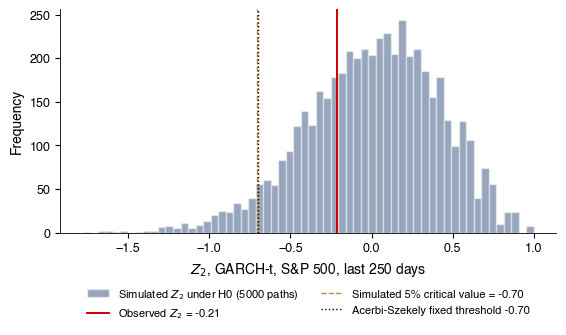

,MF_n,MF_mean,MF_t,MF_p,MF_p_normal,Z1,Z2,p2,crit5,T,Z2_last,p2_last,crit5_last,n_last
GARCH-t,192.0,0.106271,1.796752,0.0228,0.036977,-0.044570,-0.617725,0.0000,-0.152921,4959.0,-0.209918,0.2888,-0.704728,6.0
FHS,130.0,0.093171,1.213800,0.0962,0.113521,-0.040810,-0.091392,0.1536,-0.150320,4959.0,0.142024,0.6024,-0.710421,4.0
HS,156.0,0.363481,2.879161,0.0006,0.002276,-0.116912,-0.405430,0.0000,-0.153584,4959.0,0.722735,0.9754,-0.715814,2.0


In [16]:
# Rezolvare
def b3_es_sp500():
    out = {}
    for m in ('GARCH-t', 'FHS', 'HS'):
        df = fc('sp500')[0][m]
        mf = mcneil_frey(df['L'].values, df['VaR2.5'].values, df['ES2.5'].values, df['scale'].values)
        z = z2_null('sp500', m)
        zl = z2_null('sp500', m, last=250)
        out[m] = dict(MF_n=mf['n'], MF_mean=mf['mean'], MF_t=mf['t'], MF_p=mf['p'],
                      MF_p_normal=float(stats.t.sf(mf['t'], mf['n'] - 1)),
                      Z1=z['Z1'], Z2=z['Z2'], p2=z['p'], crit5=z['crit5'], T=z['T'],
                      Z2_last=zl['Z2'], p2_last=zl['p'], crit5_last=zl['crit5'], n_last=zl['n_hit'])
        if m == 'GARCH-t':
            fig, ax = plt.subplots(figsize=(6.4, 2.9))
            ax.hist(zl['sims'], bins=60, color=MainBlue, alpha=0.45, edgecolor='white', label='Simulated $Z_2$ under H0 (5000 paths)')
            ax.axvline(zl['Z2'], color=IDAred, lw=1.4, label=f'Observed $Z_2$ = {zl["Z2"]:.2f}')
            ax.axvline(zl['crit5'], color=Amber, ls='--', lw=1.0, label=f'Simulated 5% critical value = {zl["crit5"]:.2f}')
            ax.axvline(-0.70, color='black', ls=':', lw=1.0, label='Acerbi-Szekely fixed threshold -0.70')
            ax.set_xlabel(r'$Z_2$, GARCH-t, S&P 500, last 250 days')
            ax.set_ylabel('Frequency')
            legend_outside_bottom(ax, ncol=2, y=-0.2)
            save_fig('ch8_sem_z2_sim')
    return out


pd.DataFrame(b3_es_sp500()).T

### B4. $Z_2$ prin simulare pe BET și Bitcoin [Propus]

- Interpretare: de ce se schimbă verdictul între întreg eșantionul și ultimul an?

In [ ]:
# Codul vostru aici


### B5. Diebold–Mariano cu dispersie HAC [Rezolvat]

- Interpretare: când supraestimează semnificația ignorarea autocorelației?

In [18]:
# Rezolvare
def b5_dm_sp500():
    Lf = fz_losses('sp500')
    out = {}
    for a, b in (('GARCH-t', 'FHS'), ('HS', 'FHS'), ('GARCH-EVT', 'FHS')):
        d = Lf[a] - Lf[b]
        dm = diebold_mariano(Lf[a], Lf[b])
        naive = d.mean() / (d.std(ddof=1) / np.sqrt(len(d)))
        out[f'{a}|{b}'] = dict(dbar=float(d.mean()), DM=dm['DM'], p=dm['p'], naive=float(naive),
                               lrv_ratio=float(nw_var(d.values) / d.var()))
    out['mean'] = {m: float(v) for m, v in Lf.mean().items()}
    out['T'] = len(Lf)
    out['lags'] = int(np.floor(4 * (len(Lf) / 100) ** (2 / 9)))
    return out


b5_dm_sp500()

{'GARCH-t|FHS': {'dbar': 0.038839952630652416,
  'DM': np.float64(2.6531239239195106),
  'p': np.float64(0.007975058535568747),
  'naive': 2.724475179212569,
  'lrv_ratio': 1.0545098477811676},
 'HS|FHS': {'dbar': 0.4172853161596149,
  'DM': np.float64(4.696504061339195),
  'p': np.float64(2.64651975649502e-06),
  'naive': 7.179711413861121,
  'lrv_ratio': 2.3370315319875337},
 'GARCH-EVT|FHS': {'dbar': 0.0028646794128979916,
  'DM': np.float64(1.238151284470734),
  'p': np.float64(0.21565997097060086),
  'naive': 1.3073311135893915,
  'lrv_ratio': 1.1148688195632939},
 'mean': {'HS': -3.134042841441771,
  'Normal': -2.9578279082047287,
  'Student-t': -3.036176263201934,
  'GARCH-t': -3.5124882049707327,
  'FHS': -3.5513281576013855,
  'GARCH-EVT': -3.548463478188488},
 'T': 4959,
 'lags': 9}

### B6. Compararea modelelor pe Bitcoin și EUR/RON [Propus]

- Interpretare: de ce mulțimea de modele de încredere este atât de mare pentru Bitcoin?

In [ ]:
# Codul vostru aici


### B7. VaR conformal în perioade calme și de criză [Rezolvat]

- Interpretare: ce se schimbă între datele reale și cele schimbabile, acoperirea sau independența?

In [20]:
# Rezolvare
def b7_conformal_sp500():
    out = {}
    for a in (0.05, 0.01):
        r = load_returns('sp500')
        c = conformal_var(r, a=a).loc[fc('sp500')[0]['HS'].index[0]:]
        reg = regimes(r, c.index)
        hs = c['L'] > c['VaR_split']
        # simulare: aceeasi procedura pe date i.i.d. Student-t (schimbabile)
        rng = np.random.default_rng(5)
        x = pd.Series(rng.standard_t(4, len(r)) * 0.01, index=r.index)
        ci = conformal_var(x, a=a).loc[c.index[0]:]
        regi = regimes(x, ci.index)
        hi = ci['L'] > ci['VaR_split']
        out[str(a)] = dict(T=len(c), rate=float(hs.mean()), calm=float(hs[~reg].mean()), crisis=float(hs[reg].mean()),
                           kup=kupiec(hs.values, a)['p'], iid_rate=float(hi.mean()), iid_calm=float(hi[~regi].mean()),
                           iid_crisis=float(hi[regi].mean()), n_crisis=int(reg.sum()),
                           ind=christoffersen(hs.values, a)['p_ind'], ind_iid=christoffersen(hi.values, a)['p_ind'])
    return out


pd.DataFrame(b7_conformal_sp500()).T

,T,rate,calm,crisis,kup,iid_rate,iid_calm,iid_crisis,n_crisis,ind,ind_iid
0.05,4959.0,0.053438,0.051535,0.070565,0.271685,0.047389,0.047278,0.048387,496.0,0.000032,0.965171
0.01,4959.0,0.012906,0.012099,0.020161,0.049029,0.007260,0.007618,0.004032,496.0,0.001386,0.468031


### B8. VaR conformal pe BET și Bitcoin [Propus]

- Interpretare: corectează ACI acoperirea condiționată sau doar media pe termen lung?

In [ ]:
# Codul vostru aici


## Partea C — ce model de risc ați certifica pentru portofoliul de tranzacționare al unei bănci românești? [Propus]

- Un portofoliu în lei: jumătate în indicele BET, jumătate în euro evaluat la cursul de referință BNR.
- Uniți întâi prețurile pe zilele comune, apoi calculați randamentele; combinați dovezile reglementare și statistice.

In [ ]:
# Codul vostru aici
